# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: L.B.J.SUBERBERE
* Username: lbjsuberbere
* Student number: s6080081
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

In a typical system, you'd expect a galaxy's rotation to slow down as you move further from its center. But observations show that stars at the outer edges of galaxies like NGC 6946 actually move just as fast as those near the middle. This flat curve proves there is a lot of invisible mass we can't see, providing the main evidence for dark matter.


/var/folders/5s/07phjsxd1tx1_7sp_47phs380000gn/T/ipykernel_33782/2447121952.py:17: RuntimeWarning: divide by zero encountered in divide
  keplerian = (np.sqrt((G * 2e10 * M_sun.value) / (radius*3.086e19)))/1000


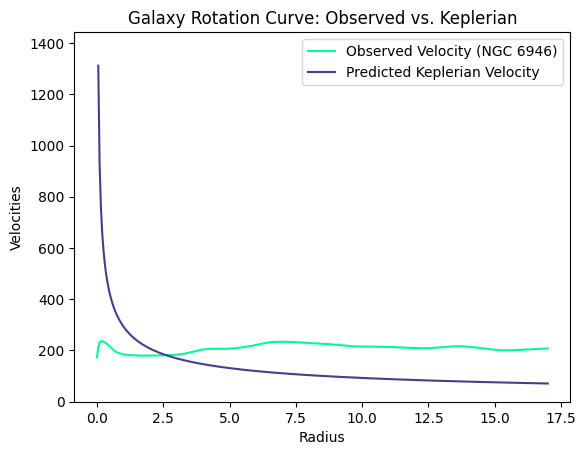

In [2]:
import numpy as np
from scipy.constants import G
from astropy.constants import M_sun
import matplotlib.pyplot as plt

#Read datas into two columns
radius , velocities = np.loadtxt('../../rotcur.dat', unpack=True)

#plotting the original data
plt.figure()
plt.plot(radius, velocities, color = 'mediumspringgreen', label='Observed Velocity (NGC 6946)')
plt.ylabel('Velocities')
plt.xlabel('Radius')
plt.title('Galaxy Rotation Curve: Observed vs. Keplerian')

#Calculating the keplerian expected velocity
keplerian = (np.sqrt((G * 2e10 * M_sun.value) / (radius*3.086e19)))/1000
keplerianchanged = np.delete(keplerian, 0) #removed because it was infitiny and it wasn't allowing plotting

#Create the text file
np.savetxt('keplerian_curve.txt', keplerianchanged)

#Load the data from the file
loaded = np.loadtxt('keplerian_curve.txt')

#Plotting Keplerian velocity
plt.plot(np.delete(radius, 0), loaded, color = 'darkslateblue', label='Predicted Keplerian Velocity')#first val of radius deleted so the arrays have same length
plt.ylim(0, np.max(loaded) * 1.1)
plt.legend()

#Observations
print('In a typical system, you\'d expect a galaxy\'s rotation to slow down as you move further from its center. But observations show that stars at the outer edges of galaxies like NGC 6946 actually move just as fast as those near the middle. This flat curve proves there is a lot of invisible mass we can\'t see, providing the main evidence for dark matter.')

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

When saving data, you always save all the relevant data in 1 file. So also try to save radius values in your `keplerian_curve.txt` file. <b>[0.5pt deducted from total grade.]</b>

Incorrect xlabel and ylabel. Units are missing. <b>[0.5pt deducted from total grade.]</b>

</div>

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 3

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

The mean 0.016031341137905903 and the standard deviation 1.0007666512516746 match the expected inital mean = 0 and std = 1.0  of the array 'data'.
Thie histogram ressembles Gaussian Distribution


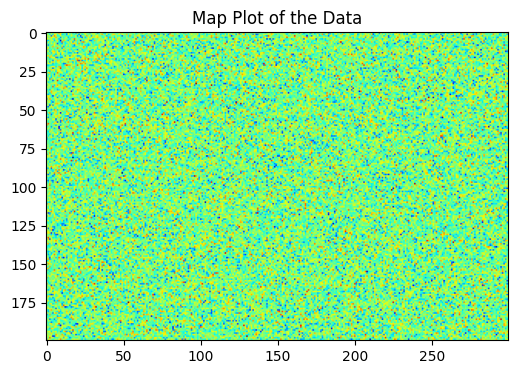

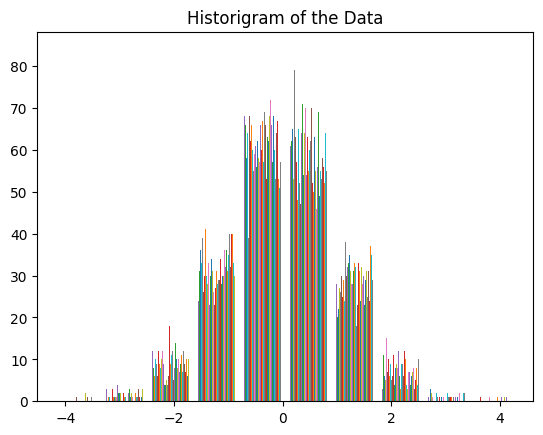

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# plt.rc('text', usetex=True)

#Generate the map plot
data = np.random.normal(0, 1.0, (200,300))
plt.figure(figsize=(8, 4))
plt.imshow(data, cmap = 'jet')
plt.title('Map Plot of the Data')

#Create a 30x30 square of the data
dataslice = data[30:60, 80:110]
mean = np.mean(dataslice)
std = np.std(dataslice)
print(f'The mean {mean} and the standard deviation {std} match the expected inital mean = 0 and std = 1.0  of the array \'data\'.')

#Printing the data as an historigram)
plt.figure()
plt.hist(data)
plt.title('Historigram of the Data')
print('Thie histogram ressembles Gaussian Distribution')

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You had to comment on the calcated mean and standard deviation of your 30x30 slice. <b>[0.5pt deducted from total grade.]</b>

Your histogram looks quite off, and is incorrect. [TIP] Look at hint in the question, it says you will need to flatten or ravel the data. <b>[0.5pt deducted from total grade.]</b>
</div>

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 2

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Perimeter of Test Galaxy A galaxy is 15.865439589251233 and its area is 18.84955592153876
For Test Galaxy B, the center is located at (150, 250), the height is 6.0, the width is 4.0, and the position angle is 60


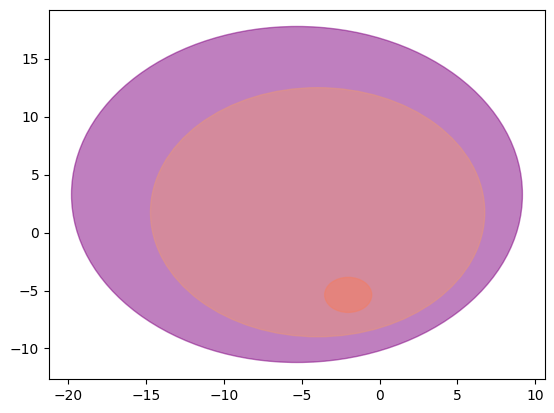

In [6]:
from matplotlib.patches import Ellipse
from math import *
import numpy as np

#Creation of the class AstroEllipse
class AstroEllipse(Ellipse):
   def __init__(self, name, xc, yc, semi_major, semi_minor, position_angle, **args): #Added the name argument for printing
       
      self.name = name
      self.semi_major = semi_major
      self.semi_minor = semi_minor #Made these variable be class variable
      
      assert(semi_major >= semi_minor) 
      
      XY = (xc, yc)                  
      angle_mpl = position_angle     
      height = 2.0*semi_major        
      width  = 2.0*semi_minor        
       
      super().__init__(XY, width, height, angle=angle_mpl, **args)
       
   def area(self):
      return np.pi*self.semi_major*self.semi_minor #Method for area calculation
       
   def perimeter(self):
      a = self.semi_major
      b = self.semi_minor
      h = ((a-b)**2)/((a+b)**2)
      P = np.pi*(a+b)*(1+((3*h)/(10 + np.sqrt(4-3*h))))
      return P        #Method for perimeter calculation
       
   def __str__(self):
      return f'For {self.name}, the center is located at {self.center}, the height is {self.height}, the width is {self.width}, and the position angle is {self.angle}' 
    #Method for printing the ellipse parameters

#First Test for methods area and parameters
gal = AstroEllipse("Test Galaxy A", 0, 0, 3, 2, 0)
print(f'Perimeter of {gal.name} galaxy is {gal.perimeter()} and its area is {gal.area()}')       

#Second Test for method str
gal2 = AstroEllipse("Test Galaxy B", 150, 250, 3, 2, 60)
print(gal2.__str__())

#Creation of another class MyCircle that herits from the class AstroEllipse
class MyCircle(AstroEllipse): 
    def __init__(self, name, xc, yc, radius, **args):
        super().__init__(name, xc, yc, radius, radius, 0, **args)

#Plotting of 3 circles with random variables
fig, ax = plt.subplots()

circle1 =  MyCircle('Circle 1', np.random.normal(0,5,1), np.random.normal(0,5,1), np.random.normal(0,10,1), color = 'purple', alpha = 0.5)
circle2 = MyCircle('Circle 2', np.random.normal(0,5,1), np.random.normal(0,5,1), np.random.normal(0,10,1), color = 'tomato', alpha = 0.5)
circle3 = MyCircle('Circle 3', np.random.normal(0,5,1), np.random.normal(0,5,1), np.random.normal(0,10,1), color = 'darksalmon', alpha = 0.5)

#Addition of the circles to the plot
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.autoscale_view() #Set the bondaries to match the circles random sizes

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Your circles don't look circular. Maybe try looking at your x-axis and y-axis. The problem and your solution can be found there. <b>[0.5pt deducted from total grade.]</b>

With axes, we meant the semi major and minor axes. Also, you don't need to add `.__str__()` in your print command. <b>[0.5pt deducted from total grade.]</b>

</div>

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 5

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

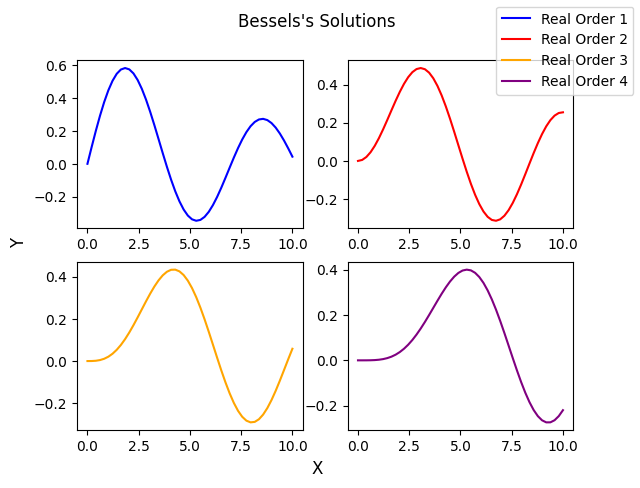

In [8]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

#plt.rc('text', usetex=True)

x = np.linspace(0,10)

#Creation of a plot with mosaic functionality
fig, ax_dict = plt.subplot_mosaic([['Real Order 1','Real Order 2'],
                                   ['Real Order 3','Real Order 4']])

fig.suptitle('Bessels\'s Solutions')

#Addition of the plots to the positions indicated in the mosaic
ax = ax_dict['Real Order 1']
ax.plot(x, jv(1,x), label = 'Real Order 1', color = 'blue')

ax = ax_dict['Real Order 2']
ax.plot(x, jv(2,x), label = 'Real Order 2', color = 'red')

ax = ax_dict['Real Order 3']
ax.plot(x, jv(3,x), label = 'Real Order 3', color = 'orange')

ax = ax_dict['Real Order 4']
ax.plot(x, jv(4,x),  label = 'Real Order 4', color = 'purple')

fig.supxlabel('X')
fig.supylabel('Y')
fig.legend()

#Saving the generated plot as a png file
fig.savefig(fname = 'PNJ1.png')

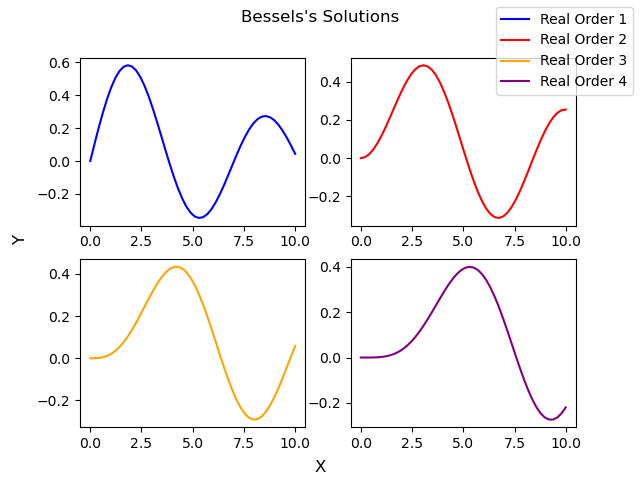

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

We want you to add x-axis, y-axis, title and legend to each plot individually.  <b>[1pt deducted from total grade.]</b>

You used functions that make the plotting not 100% Object Oriented Plotting. Try to avoid to use of `plt.`, the only exception is `plt.show()`. <b>[1pt deducted from total grade.]</b>

</div>

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 1

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

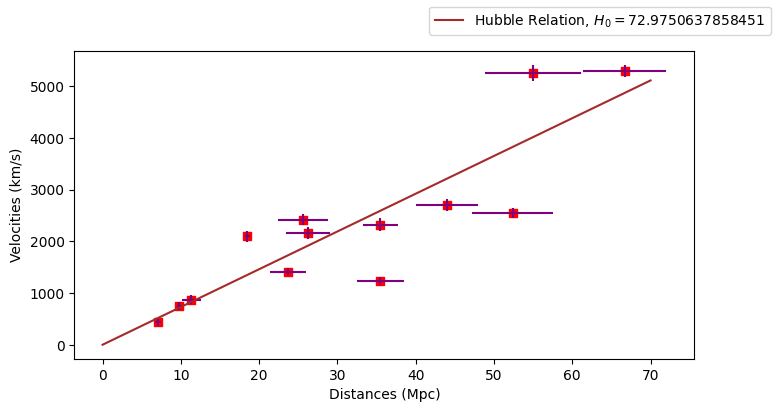

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = [
18.49,     2094.75,    0.3,           100,
35.48,     2320.87,    2.2,           120,
35.48,     1224.9,     3.0,           80,
11.34,     872.13,     1.2,           80,
7.12,      432.2,      0.4,           70,
9.82,      751,        0.3,           75,
23.66,     1410,       2.3,           70,
44,        2700,       4.0,           110,
66.7,      5292,       5.3,           120,
52.4,      2550,       5.2,           100,
55,        5253,       6.1,           150,
25.6,      2419,       3.2,           110,
26.19,     2158,       2.8,           110
]

#Slicing to create new arrays from each colums
distances = data[0:52:4]
velocities = data[1:52:4]
distances_error = data[2:52:4]
velocities_error = data[3:52:4]

#plt.rc('text', usetex=True)

#Calculation of Hubble's constant value
val = np.array(velocities)/np.array(distances) 
H_0 = np.mean(val)

#Plotting of scatter points and the correspondng errors
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(distances, velocities, color='red', marker='s')
ax.errorbar(distances, velocities, yerr=velocities_error, xerr=distances_error, 
            color='purple', fmt='none')

#Plotting of the Hubble's relation
ax.plot(np.linspace(0, 70), H_0*np.linspace(0, 70), color = 'brown', label = 'Hubble Relation, $H_0 = {}$'.format(H_0))

ax.set_xlabel('Distances (Mpc)')
ax.set_ylabel('Velocities (km/s)')
fig.legend()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Your hubble constant is incorrect. We want you to use the one known from litrature. <b>[0.5pt deducted from total grade.]</b>
</div>

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 1.5

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 12.5.  Task Grade = 6.9
